Data analysis for Student social media uses and its impact on there metal health score 

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
df=pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [119]:
df.describe(include='all').sample(2)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
count,5000.0000,5000,5000,5000,5000,5000,5000.00000,5000.0000,5000.00000,5000.000,5000.00000,5000,5000.00000
mean,20.8218,NaN,NaN,NaN,NaN,NaN,5.07846,171.4526,3.00842,1.751,6.63458,NaN,6.23098


In [120]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

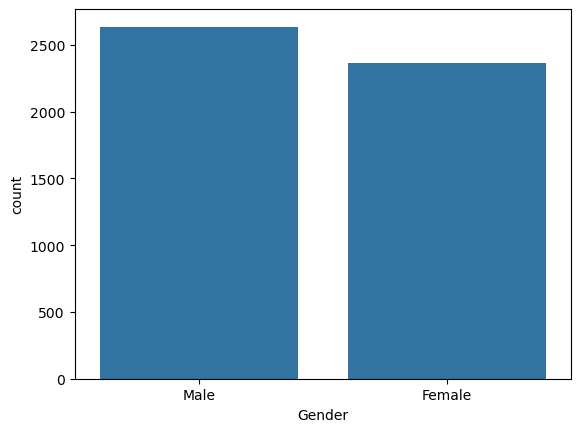

In [121]:
sns.countplot(data=df , x='Gender')
plt.show()

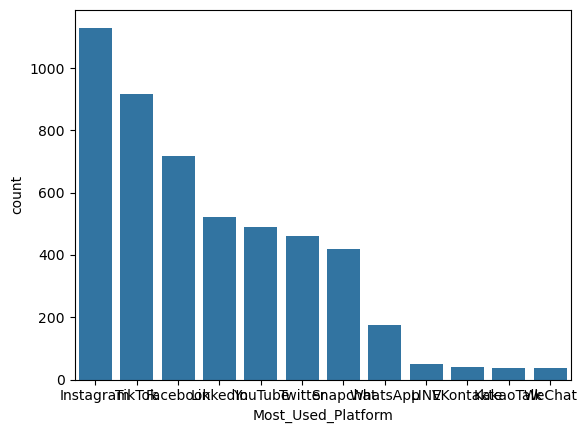

In [122]:
sns.countplot(data=df, x='Most_Used_Platform', order=df['Most_Used_Platform'].value_counts().index)

plt.show()


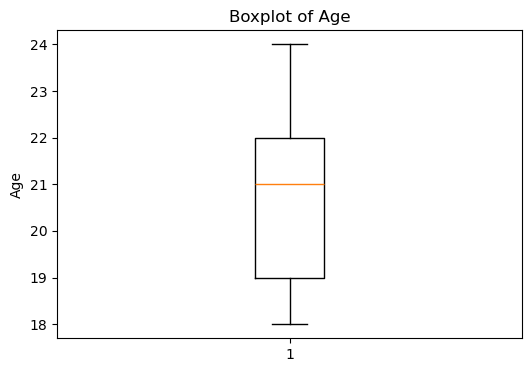

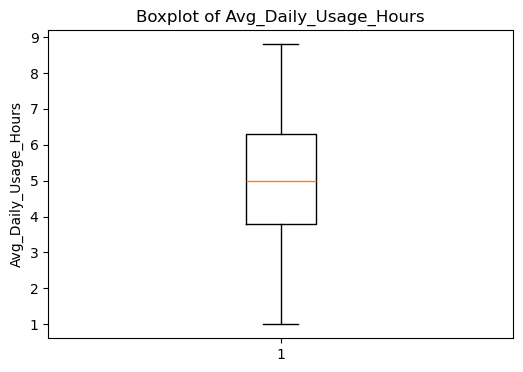

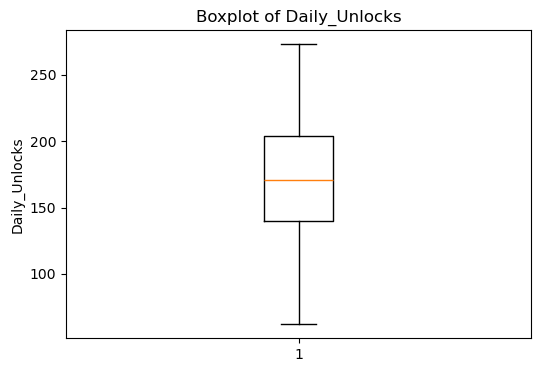

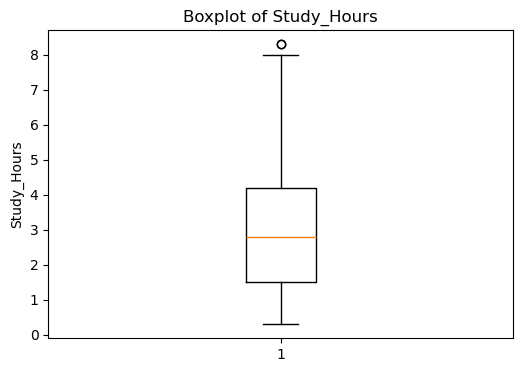

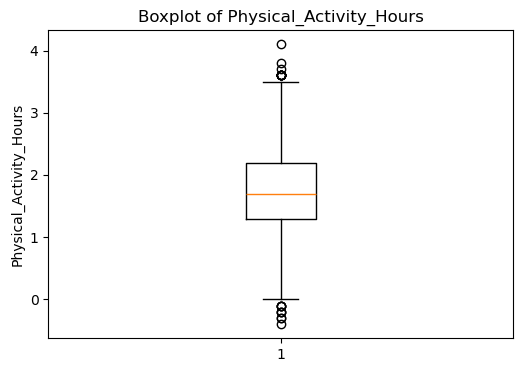

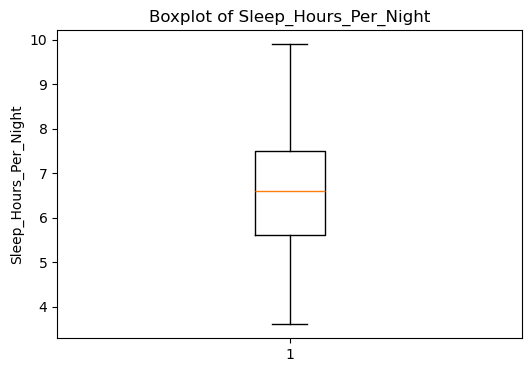

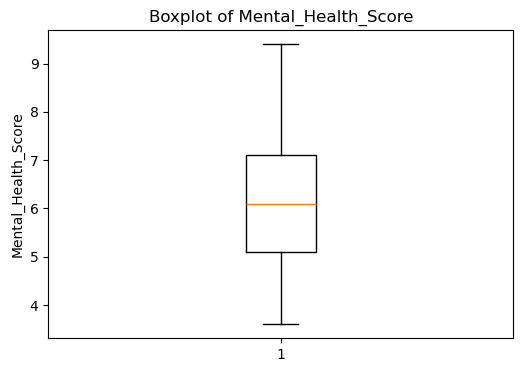

In [123]:
# only physical activity columsn do have outliers 
num_cols = df.select_dtypes(include='number').columns


for col in num_cols:
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [79]:
# bivariate analaysis
[df.columns]

[Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
        'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
        'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
        'Stress_Level', 'Mental_Health_Score'],
       dtype='object')]

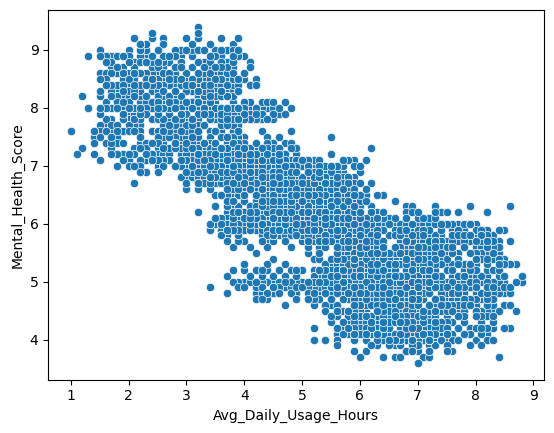

In [124]:
sns.scatterplot(data=df , x='Avg_Daily_Usage_Hours' , y = 'Mental_Health_Score')
plt.show()

# here we can notice that there is inverse relationship exit between avg daily usage hours vs mental health score 

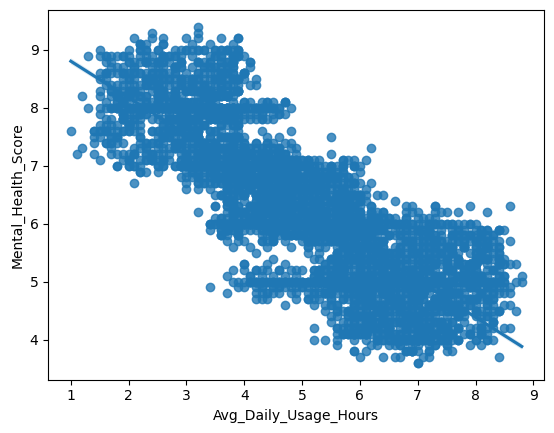

In [125]:
sns.regplot(data=df , x='Avg_Daily_Usage_Hours' , y = 'Mental_Health_Score')
plt.show()

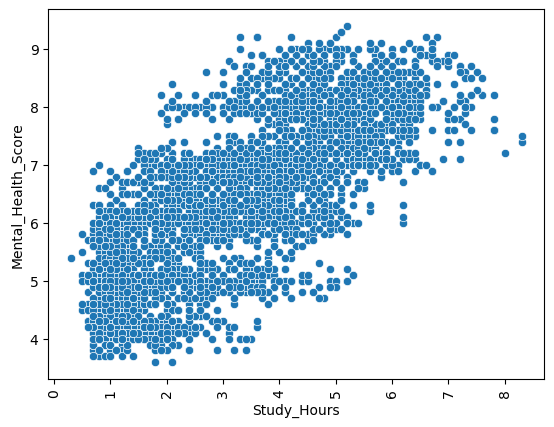

In [126]:
sns.scatterplot(data=df , x='Study_Hours' , y = 'Mental_Health_Score')
plt.xticks(rotation='vertical')
plt.show()
# here we have directly proportional relation between two columns 

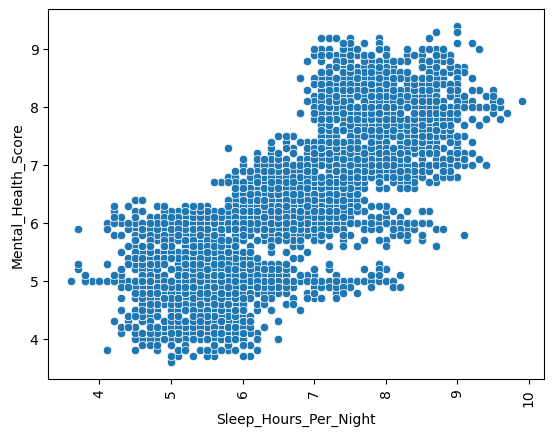

In [127]:
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night' , y = 'Mental_Health_Score')
plt.xticks(rotation='vertical')
plt.show()

# 'Stress_Level', 'Mental_Health_Score'

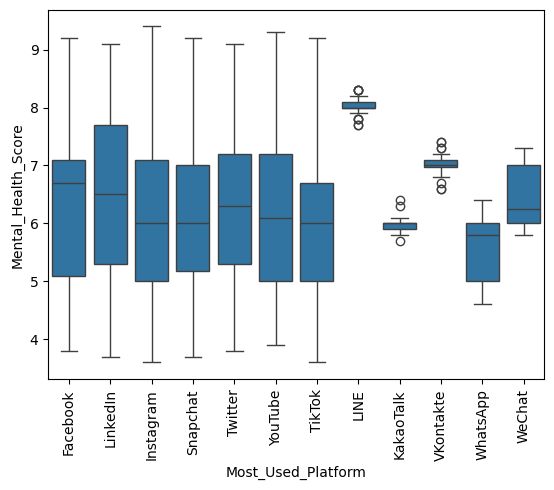

In [128]:
sns.boxplot(data=df, x='Most_Used_Platform' , y = 'Mental_Health_Score')
plt.xticks(rotation='vertical')

plt.show()

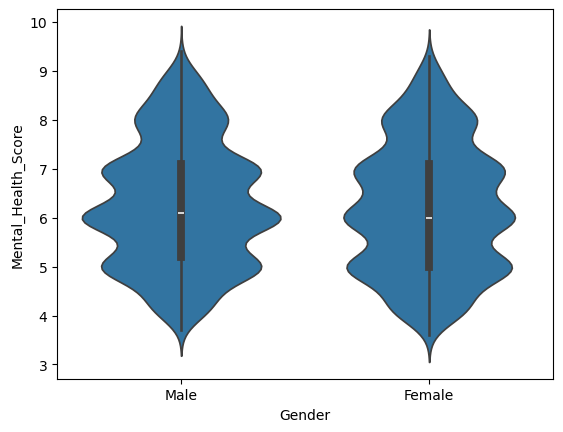

In [129]:
sns.violinplot(data=df, x='Gender',y='Mental_Health_Score')
plt.show()

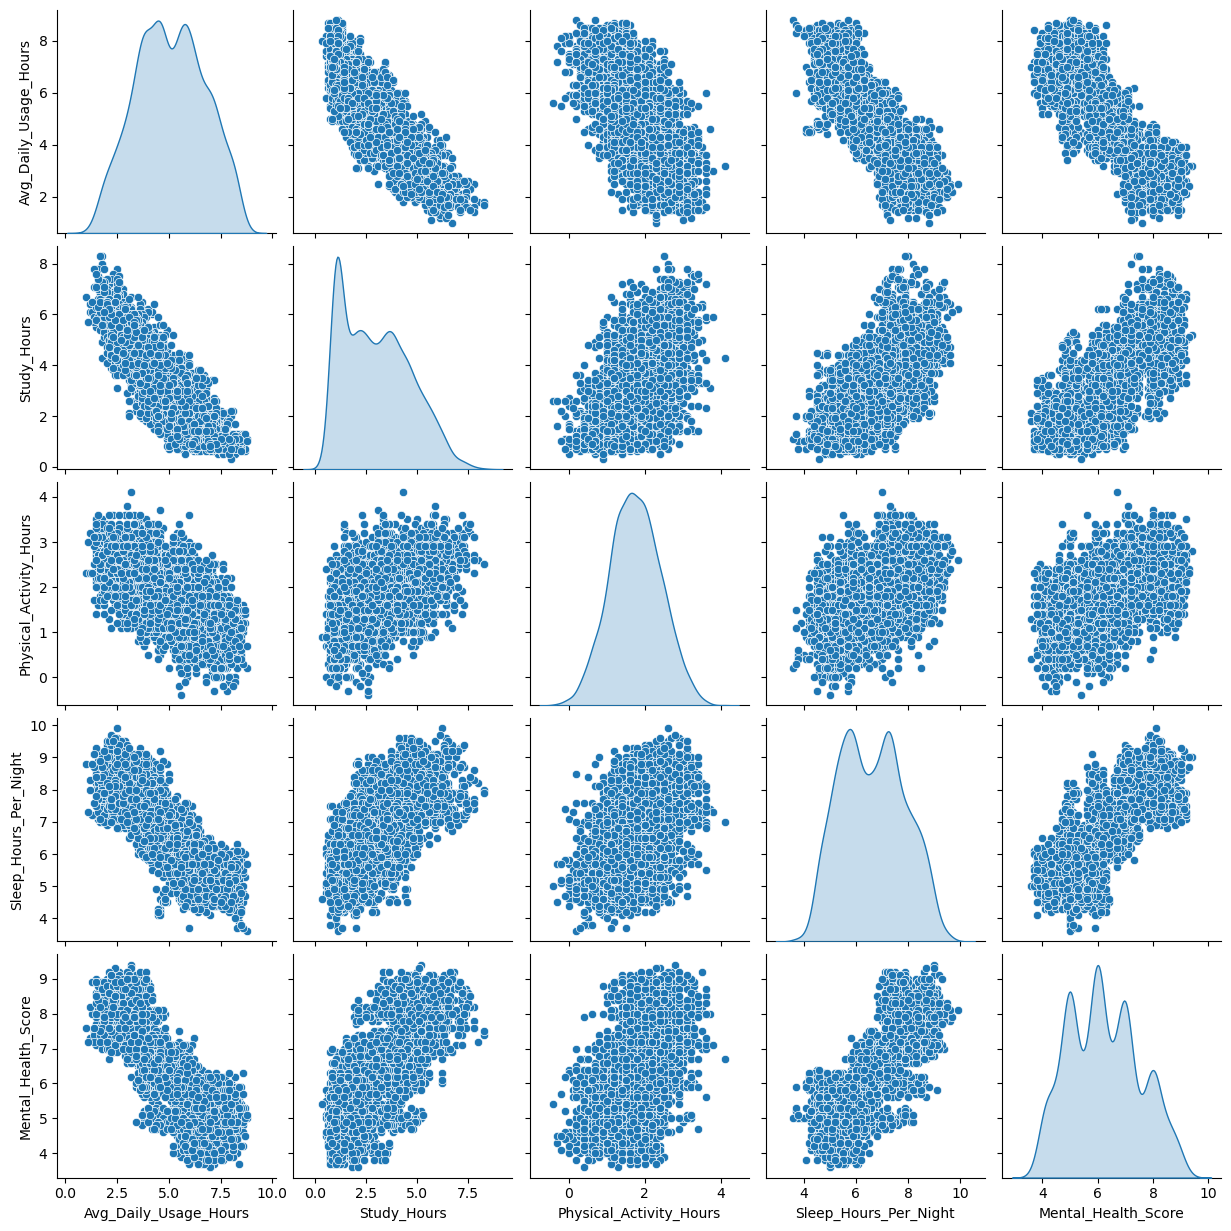

In [130]:
cols=['Avg_Daily_Usage_Hours', 
        'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
         'Mental_Health_Score']
sns.pairplot(df[cols] , diag_kind='kde')
plt.show()

In [132]:
# correlation matrix 
corr=df.corr(numeric_only=True)
print(corr)

                              Age  Avg_Daily_Usage_Hours  Daily_Unlocks  \
Age                      1.000000              -0.070092      -0.074488   
Avg_Daily_Usage_Hours   -0.070092               1.000000       0.960187   
Daily_Unlocks           -0.074488               0.960187       1.000000   
Study_Hours              0.083109              -0.878645      -0.853397   
Physical_Activity_Hours  0.012984              -0.625707      -0.602828   
Sleep_Hours_Per_Night    0.088681              -0.808388      -0.781823   
Mental_Health_Score      0.100785              -0.816453      -0.790851   

                         Study_Hours  Physical_Activity_Hours  \
Age                         0.083109                 0.012984   
Avg_Daily_Usage_Hours      -0.878645                -0.625707   
Daily_Unlocks              -0.853397                -0.602828   
Study_Hours                 1.000000                 0.560532   
Physical_Activity_Hours     0.560532                 1.000000   
Sleep_Hou

In [133]:
df.replace({'Gender':{'Male':0,'Female':1}},inplace=True)
df.replace({'Academic_Level':{'High School':0 , 'Undergraduate':1,'Graduate':2}},inplace=True)
df.replace({'Purpose_Of_Use':{'Networking':0 , 'Education':1,'Entertainment':2,'News':3}},inplace=True)
df.replace({'Stress_Level':{'Low':0 , 'Medium':1,'High':2,'Very High':3}},inplace=True)


/tmp/ipykernel_260/2553745345.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Gender':{'Male':0,'Female':1}},inplace=True)
/tmp/ipykernel_260/2553745345.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Academic_Level':{'High School':0 , 'Undergraduate':1,'Graduate':2}},inplace=True)
/tmp/ipykernel_260/2553745345.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`.

In [134]:
df.sample(3)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2764,23,0,India,2,Twitter,3,7.1,234,1.0,0.3,5.2,3,5.7
4139,18,0,Germany,0,YouTube,1,6.2,215,2.1,1.0,4.9,3,5.0
1267,22,0,Russia,1,VKontakte,2,4.3,142,2.2,1.9,7.7,1,7.0


In [136]:
df_num=df.drop(['Country','Age','Most_Used_Platform'],axis=1)

In [137]:
df_num

,Gender,Academic_Level,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,0,1,0,4.0,134,4.5,2.2,6.7,1,6.8
1,1,2,1,1.6,73,7.0,2.4,8.6,0,7.6
2,0,1,2,4.6,166,4.0,1.8,6.7,1,7.0
3,0,0,2,7.0,220,1.0,1.7,5.4,3,5.3
4,1,2,0,7.5,237,1.0,1.1,5.0,3,4.4
...,...,...,...,...,...,...,...,...,...,...
4995,1,0,1,1.9,89,6.1,2.2,7.9,0,7.9
4996,1,0,1,6.6,216,2.3,1.8,6.0,3,4.7
4997,1,1,1,3.8,151,5.4,1.4,7.5,1,7.0
4998,0,0,2,3.8,119,4.0,1.5,6.4,1,6.7


In [138]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   5000 non-null   int64  
 1   Academic_Level           5000 non-null   int64  
 2   Purpose_Of_Use           5000 non-null   int64  
 3   Avg_Daily_Usage_Hours    5000 non-null   float64
 4   Daily_Unlocks            5000 non-null   int64  
 5   Study_Hours              5000 non-null   float64
 6   Physical_Activity_Hours  5000 non-null   float64
 7   Sleep_Hours_Per_Night    5000 non-null   float64
 8   Stress_Level             5000 non-null   int64  
 9   Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 390.8 KB


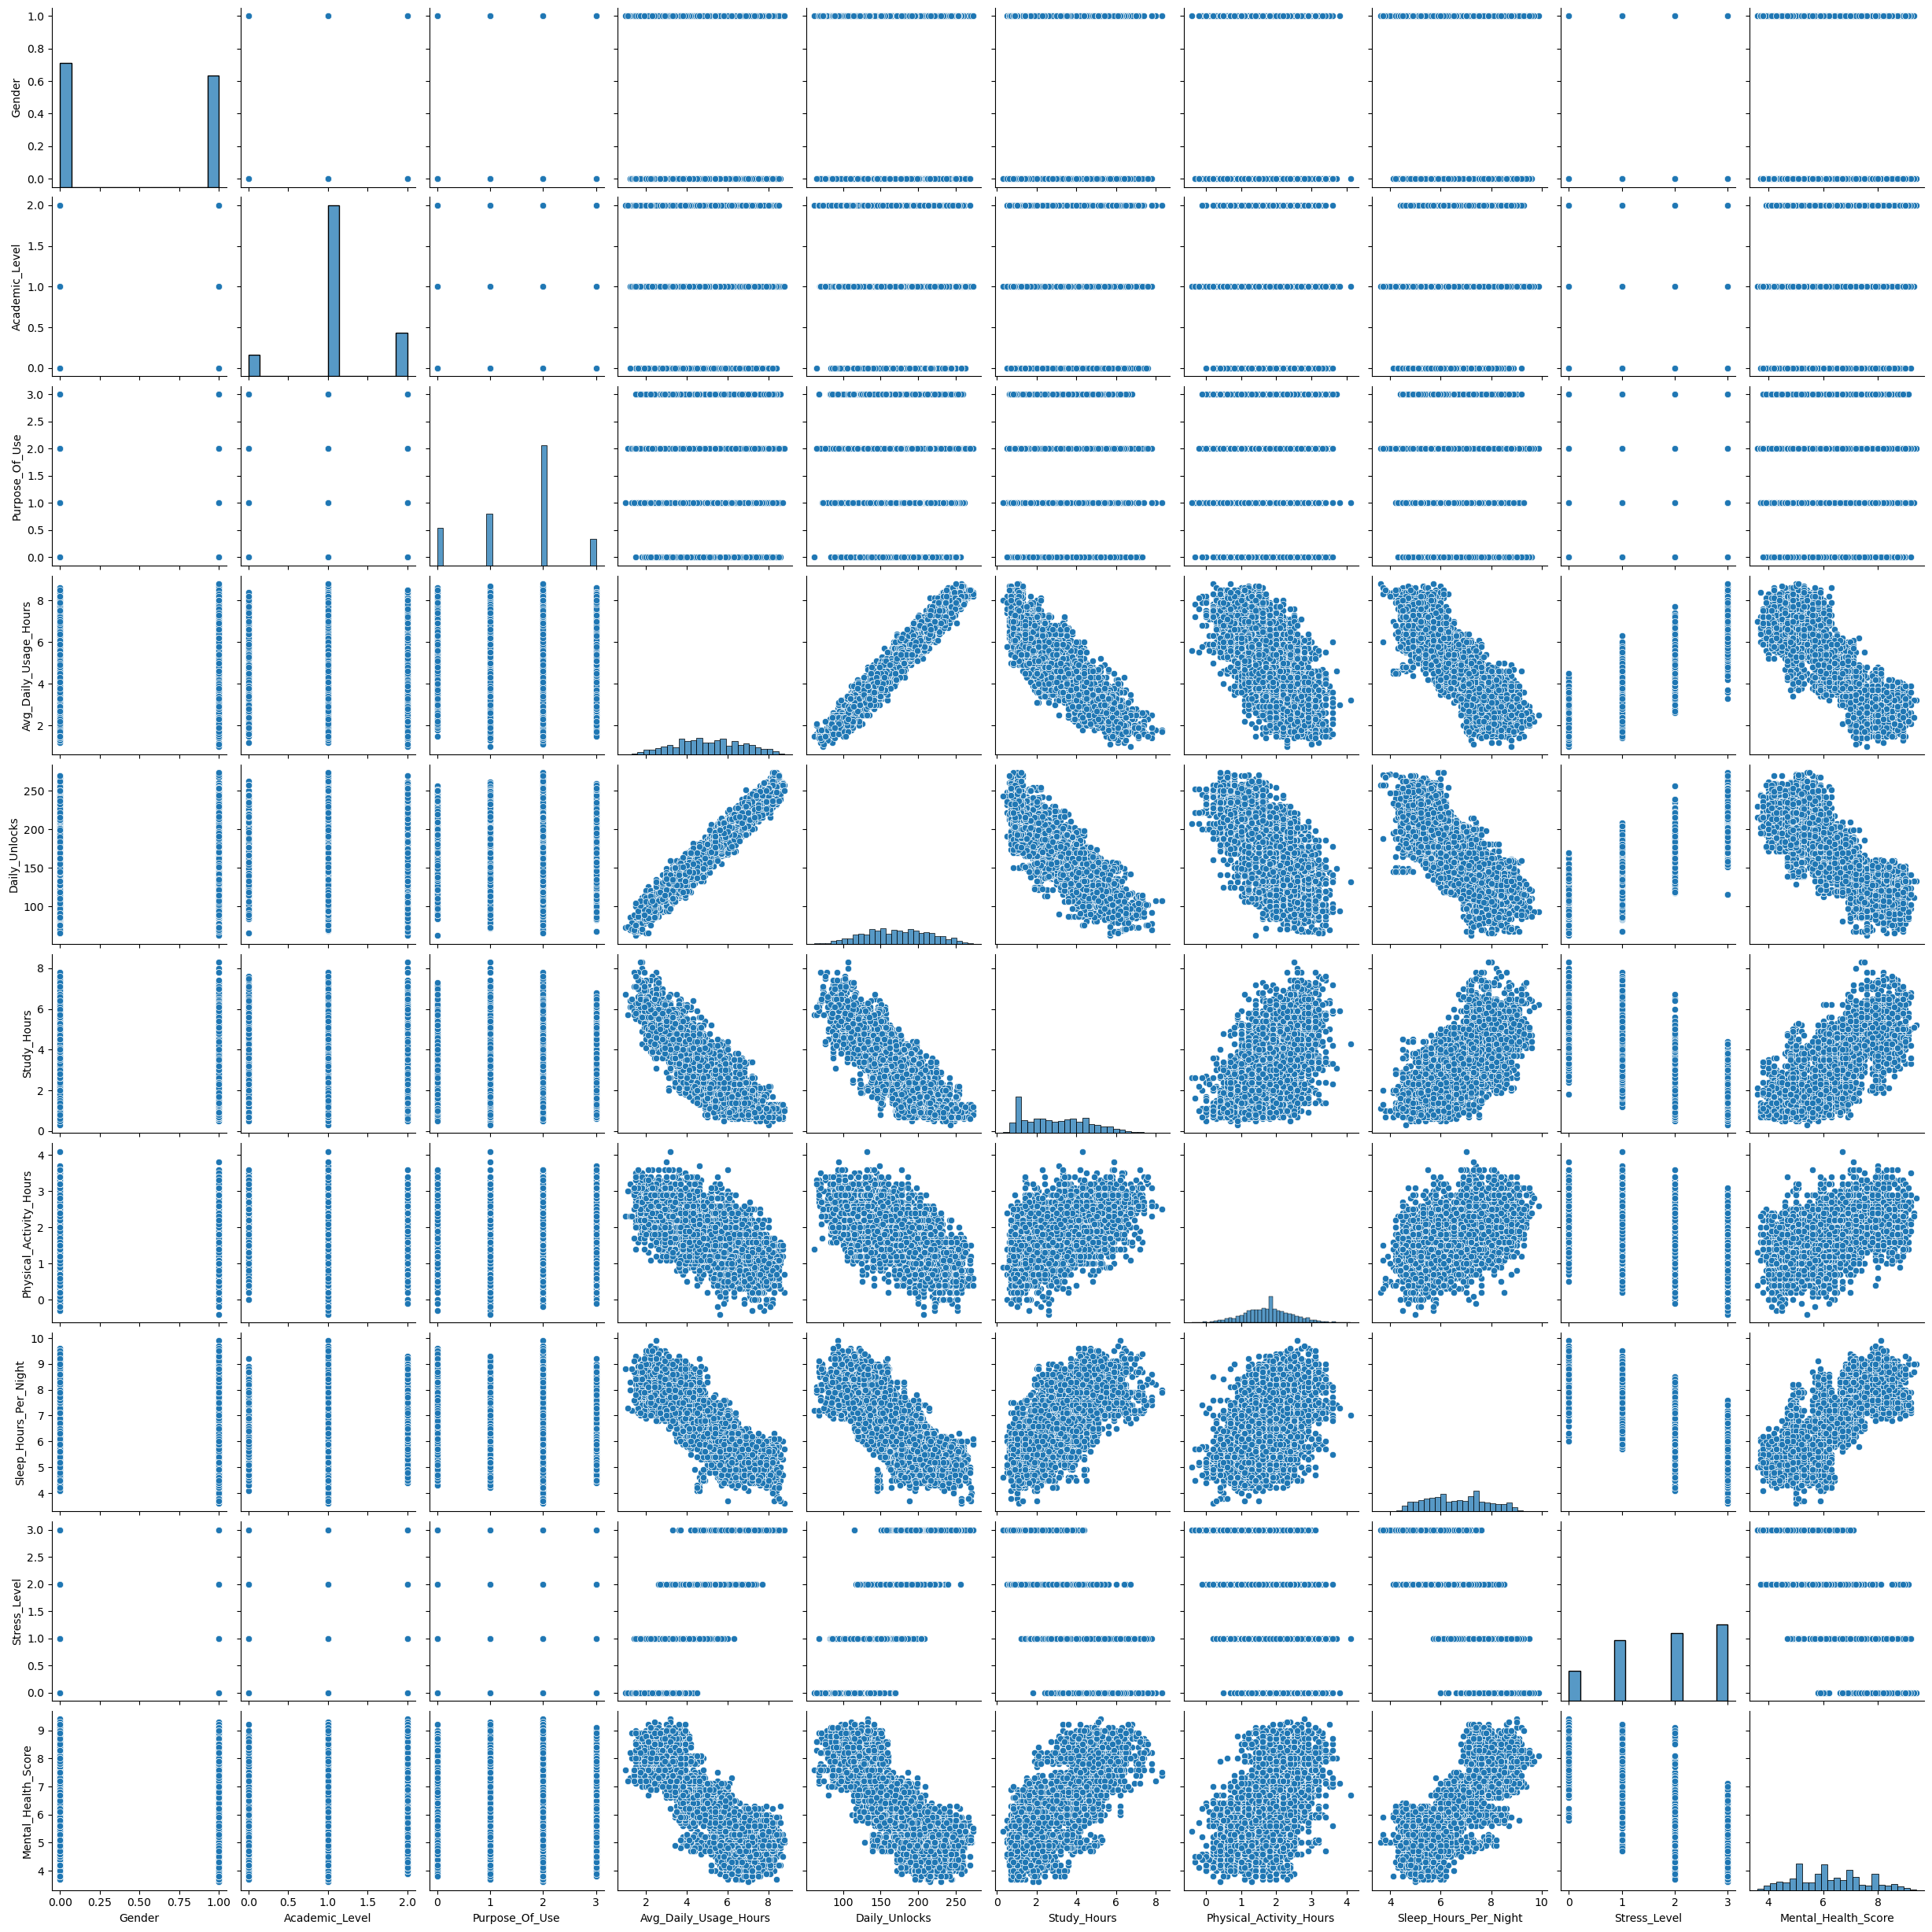

In [139]:
sns.pairplot(df_num)
plt.show()

In [140]:
df_num.columns

Index(['Gender', 'Academic_Level', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours',
       'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours',
       'Sleep_Hours_Per_Night', 'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [141]:
df_num.shape

(5000, 10)

In [142]:
df_num.columns.tolist()

['Gender',
 'Academic_Level',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

In [143]:
df.duplicated().sum()

2

In [144]:
df_num.nunique()

Gender                       2
Academic_Level               3
Purpose_Of_Use               4
Avg_Daily_Usage_Hours       79
Daily_Unlocks              200
Study_Hours                 76
Physical_Activity_Hours     44
Sleep_Hours_Per_Night       63
Stress_Level                 4
Mental_Health_Score         59
dtype: int64

In [145]:
df_num=df_num.drop_duplicates()


In [146]:
df_num.shape

(4998, 10)

In [147]:
df_num.sample(1)

,Gender,Academic_Level,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2147,1,1,2,4.5,143,3.1,1.4,8.0,1,7.8


In [148]:
# correlation matrix 
corr=df_num.corr(numeric_only=True)
print(corr)

                           Gender  Academic_Level  Purpose_Of_Use  \
Gender                   1.000000        0.024635        0.077653   
Academic_Level           0.024635        1.000000       -0.013450   
Purpose_Of_Use           0.077653       -0.013450        1.000000   
Avg_Daily_Usage_Hours    0.027730       -0.066919        0.039686   
Daily_Unlocks            0.034693       -0.067821        0.038863   
Study_Hours             -0.024599        0.066992       -0.057293   
Physical_Activity_Hours -0.002757        0.015787       -0.024208   
Sleep_Hours_Per_Night   -0.018676        0.090311       -0.066313   
Stress_Level             0.026481       -0.071359        0.036626   
Mental_Health_Score     -0.033338        0.094908       -0.055702   

                         Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  \
Gender                                0.027730       0.034693    -0.024599   
Academic_Level                       -0.066919      -0.067821     0.066992   
Purpos

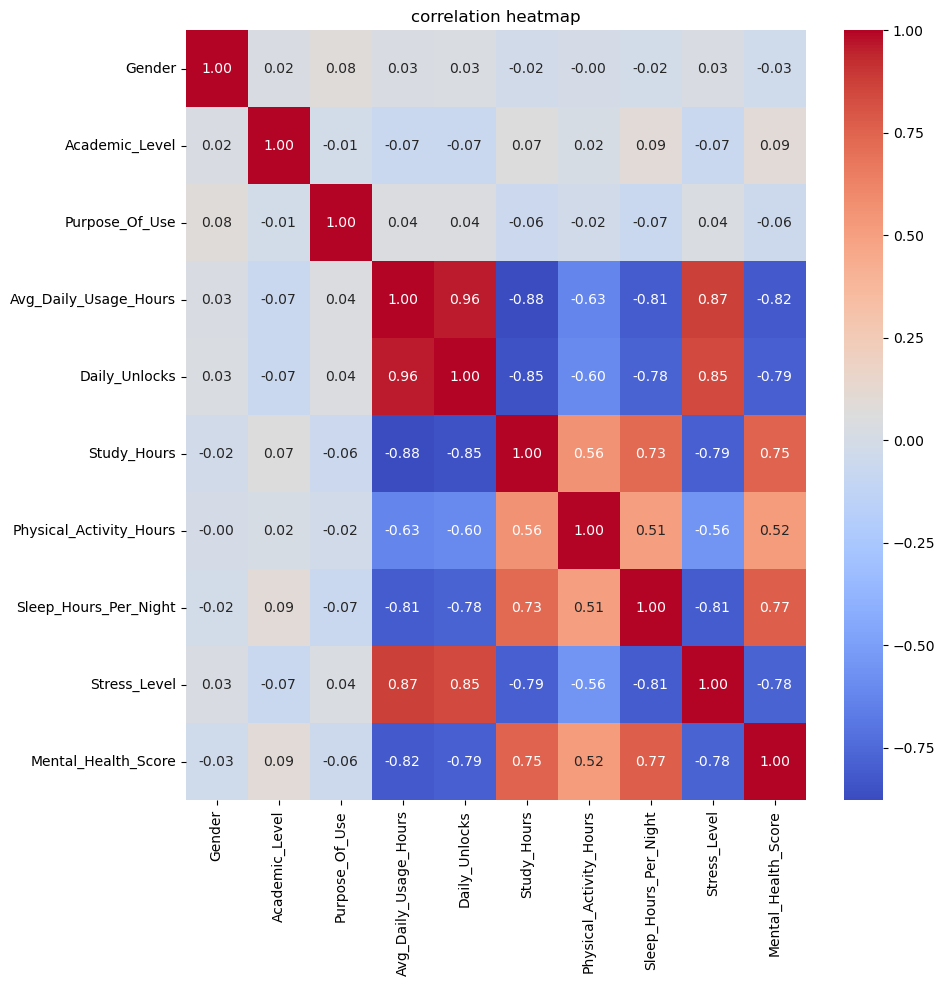

In [149]:
plt.figure(figsize=(10,10))
sns.heatmap(corr , annot=True , cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap')
plt.show()

In [150]:
df_num.skew()

Gender                     0.108234
Academic_Level             0.134900
Purpose_Of_Use            -0.431204
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.040623
Sleep_Hours_Per_Night      0.123919
Stress_Level              -0.316107
Mental_Health_Score        0.207086
dtype: float64

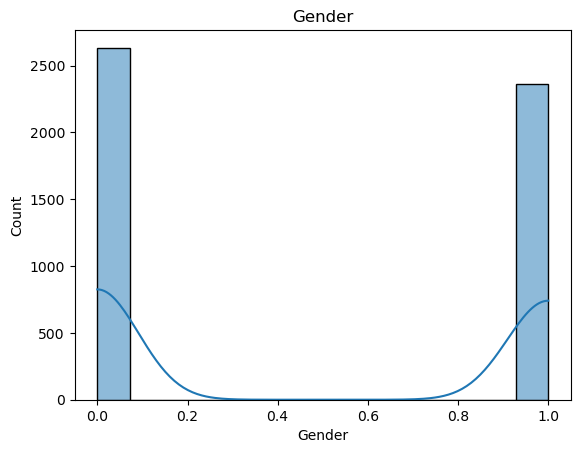

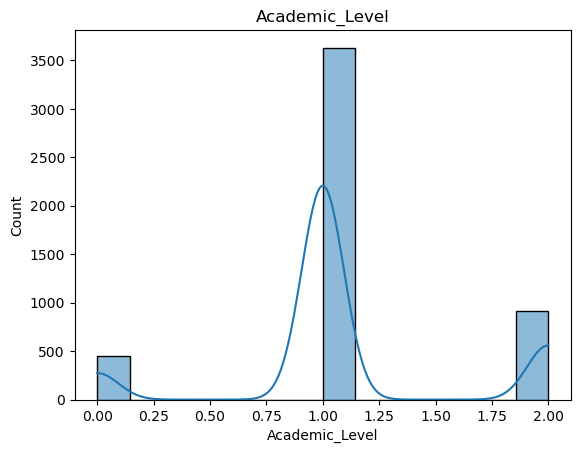

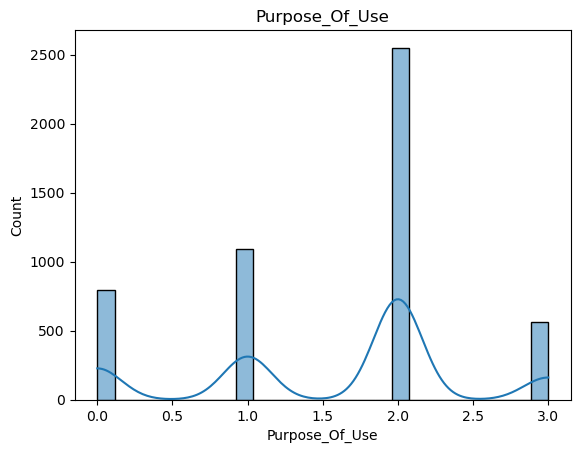

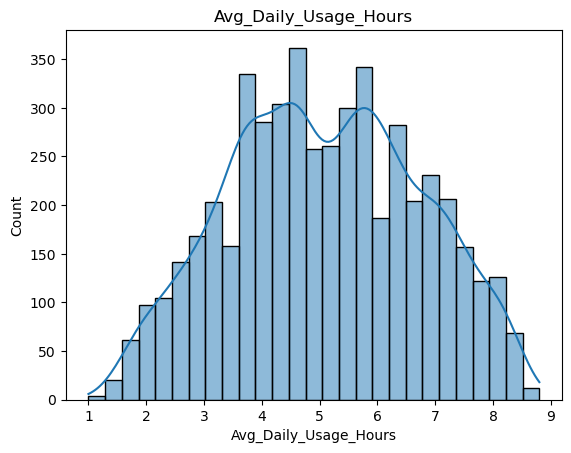

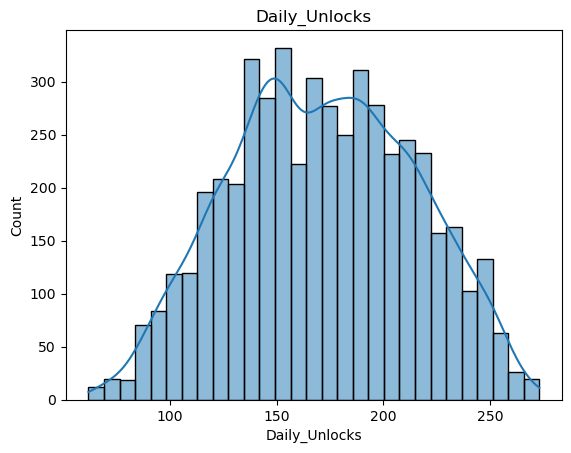

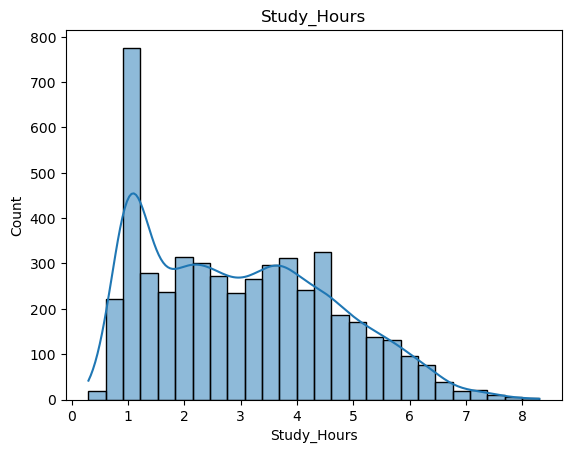

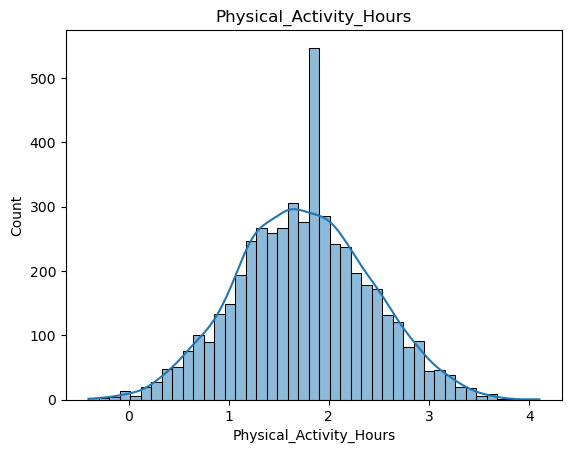

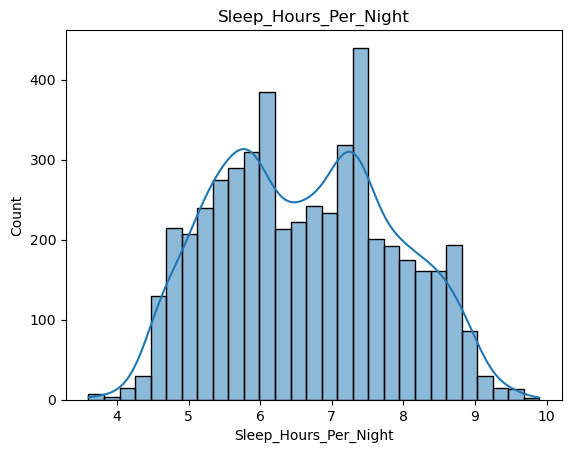

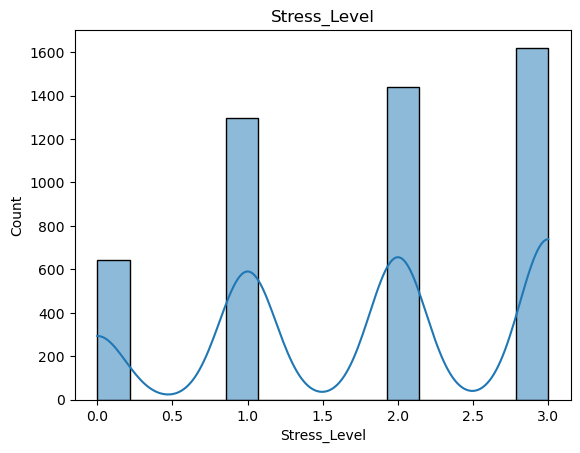

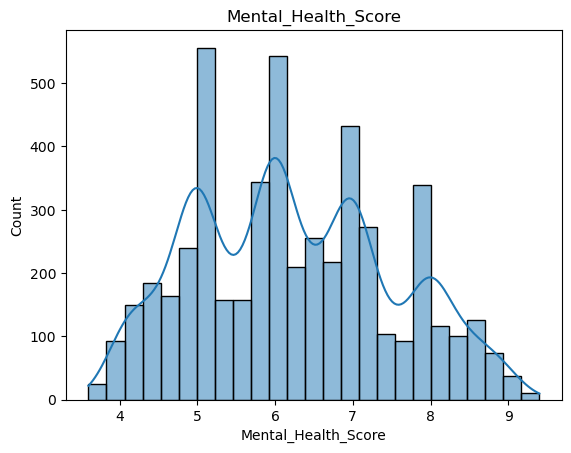

In [151]:
import seaborn as sns 
import matplotlib.pyplot as plt

for col in df_num:
    sns.histplot(df_num[col],kde=True )
    plt.title(col)
    plt.show()

In [152]:
# now we have coulumsn that have corelation with final output Mental_Health_Score 
# we will use ML model to take 'Gender','Academic_Level', 'Purpose_of_usage','Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
      # 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','stress_level' these 9 columns as input and predict output Mental_health_Score


In [158]:
df_num.sample(2)

,Gender,Academic_Level,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
560,0,1,3,4.8,158,2.7,1.9,6.9,1,6.1
648,0,1,3,5.5,190,3.1,2.0,7.1,1,7.0


In [159]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np


In [160]:
x=df_num.iloc[:,0:9]
x.sample(2)

,Gender,Academic_Level,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level
4831,1,0,2,3.9,114,3.8,1.9,6.9,1
2427,0,1,1,8.1,260,1.2,1.6,5.5,3


In [162]:
y=df_num.iloc[:, -1]
y

0       6.8
1       7.6
2       7.0
3       5.3
4       4.4
       ... 
4995    7.9
4996    4.7
4997    7.0
4998    6.7
4999    6.1
Name: Mental_Health_Score, Length: 4998, dtype: float64

In [163]:
x_train,x_test,y_train, y_test= train_test_split(x,y,test_size=0.3,random_state=42)



In [164]:
df_num.shape

(4998, 10)

In [165]:
x_train.shape

(3498, 9)

In [166]:
y_train.shape

(3498,)

In [51]:
#Train the model 

In [224]:
stu=LinearRegression()
stu.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [252]:
y_pred=stu.predict(x_test)
y_pred

array([4.62419965, 5.69642803, 5.02785052, ..., 5.9076924 , 7.51625854,
       6.5545982 ])

In [251]:
print("coefficients:", model.coef_)
print("intercept:",model.intercept_)
print("R2 score:", r2_score(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))



coefficients: [-0.02921313  0.06927948 -0.01381775 -0.26499125 -0.00092476  0.09701603
  0.02048208  0.25405052 -0.16797632]
intercept: 5.976268749193315
R2 score: 0.7236969767069386
RMSE: 0.6966292464939631


In [253]:
df_num.head(4)

,Gender,Academic_Level,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,0,1,0,4.0,134,4.5,2.2,6.7,1,6.8
1,1,2,1,1.6,73,7.0,2.4,8.6,0,7.6
2,0,1,2,4.6,166,4.0,1.8,6.7,1,7.0
3,0,0,2,7.0,220,1.0,1.7,5.4,3,5.3


In [246]:
results=pd.DataFrame({
    "actual":y_test.values,
    "predicted":y_pred
})

In [258]:
y_pred=stu.predict(x_test)

results=pd.DataFrame({
    "actual":y_test.values,
    "predicted":y_pred,
    "difference":y_test.values - y_pred
})
print(results)

      actual  predicted  difference
0        5.3   4.624200    0.675800
1        5.8   5.696428    0.103572
2        3.8   5.027851   -1.227851
3        5.6   4.720542    0.879458
4        7.5   7.919460   -0.419460
...      ...        ...         ...
1495     3.7   4.896845   -1.196845
1496     5.0   4.385785    0.614215
1497     5.9   5.907692   -0.007692
1498     8.0   7.516259    0.483741
1499     5.0   6.554598   -1.554598

[1500 rows x 3 columns]


In [260]:
results.to_csv('predicted_student_social_media.csv',index=False)